In [1]:
from sklearn.datasets import load_iris
iris = load_iris()

In [3]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [20]:
import pandas as pd 
df = pd.DataFrame(iris['data'])
df.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [18]:
df = df.drop([2,3], axis = 'columns')
df.head()

,0,1
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


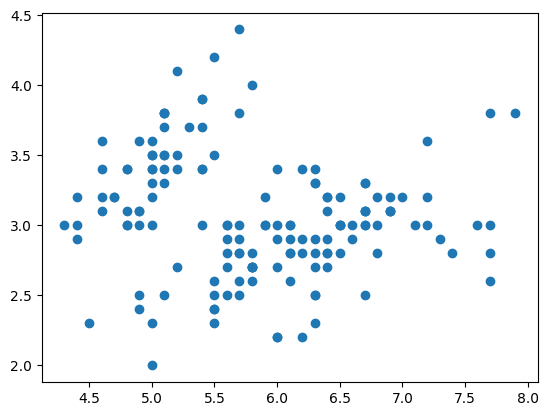

In [21]:
import matplotlib.pyplot as plt
plt.scatter(df[0], df[1])

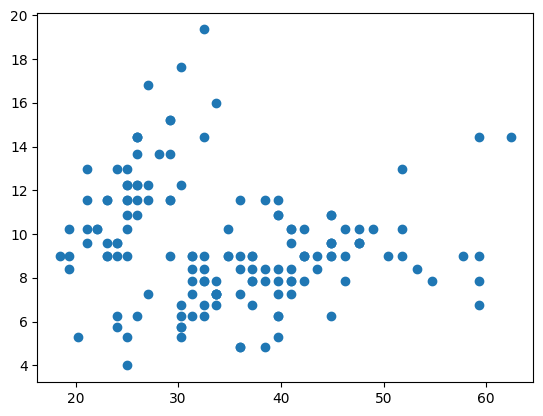

In [25]:
df['0_squared'] = df[0]**2
df['1_squared'] = df[1]**2
plt.scatter(df['0_squared'], df['1_squared'])

In [24]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [30]:
km = KMeans(n_clusters = 3)
y_pred = km.fit_predict(df[[0, 1]])
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

In [31]:
df['cluster'] = y_pred
df.head()

,0,1,2,3,0_squared,1_squared,cluster
0,5.1,3.5,1.4,0.2,26.01,12.25,0
1,4.9,3.0,1.4,0.2,24.01,9.00,0
2,4.7,3.2,1.3,0.2,22.09,10.24,0
3,4.6,3.1,1.5,0.2,21.16,9.61,0
4,5.0,3.6,1.4,0.2,25.00,12.96,0


In [45]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [33]:
df = df.drop(['0_squared', '1_squared'], axis = 'columns')

In [34]:
km.cluster_centers_

array([[5.00392157, 3.40980392],
       [6.82391304, 3.07826087],
       [5.8       , 2.7       ]])

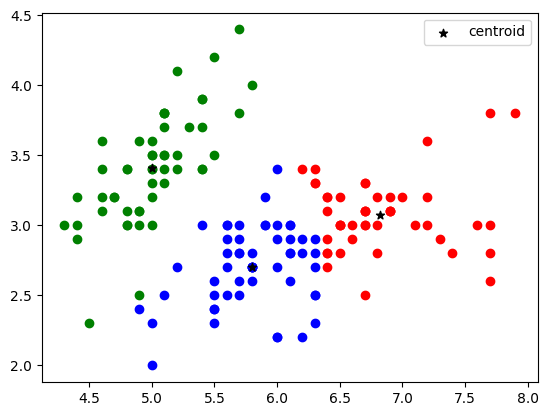

In [47]:
a = df[df.cluster == 0]
b = df[df.cluster == 1]
c = df[df.cluster == 2]
plt.scatter(a[0], a[1], color='green')
plt.scatter(b[0], b[1], color='red')
plt.scatter(c[0], c[1], color='blue')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],color='black', marker='*', label='centroid')
plt.legend()

Preprocessing using min max scaler

In [48]:
scaler = MinMaxScaler()

scaler.fit(df[[1]])
df[1] = scaler.transform(df[[1]])

scaler.fit(df[[0]])
df[0] = scaler.transform(df[[0]])

In [49]:
df.head()

,0,1,2,3,cluster
0,0.222222,0.625000,1.4,0.2,0
1,0.166667,0.416667,1.4,0.2,0
2,0.111111,0.500000,1.3,0.2,0
3,0.083333,0.458333,1.5,0.2,0
4,0.194444,0.666667,1.4,0.2,0


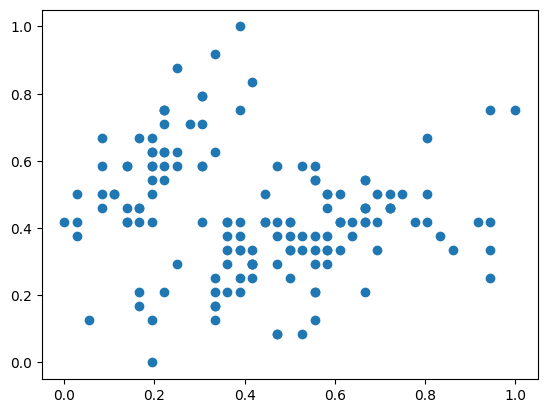

In [50]:
plt.scatter(df[0], df[1])

In [51]:
km = KMeans(n_clusters=3)
y_pred = km.fit_predict(df[[0,1]])
y_pred

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0], dtype=int32)

In [52]:
df['cluster'] = y_pred
df.head()

,0,1,2,3,cluster
0,0.222222,0.625000,1.4,0.2,2
1,0.166667,0.416667,1.4,0.2,2
2,0.111111,0.500000,1.3,0.2,2
3,0.083333,0.458333,1.5,0.2,2
4,0.194444,0.666667,1.4,0.2,2


In [53]:
km.cluster_centers_

array([[0.390625  , 0.26649306],
       [0.67557652, 0.44654088],
       [0.19897959, 0.60459184]])

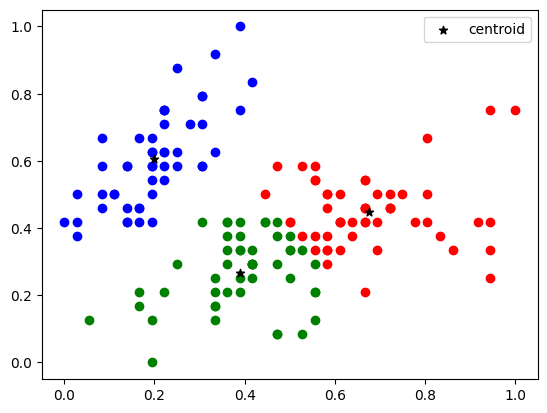

In [54]:
a = df[df.cluster == 0]
b = df[df.cluster == 1]
c = df[df.cluster == 2]
plt.scatter(a[0], a[1], color='green')
plt.scatter(b[0], b[1], color='red')
plt.scatter(c[0], c[1], color='blue')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],color='black', marker='*', label='centroid')
plt.legend()

Elbow Plot

In [55]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[[0,1]])
    sse.append(km.inertia_)

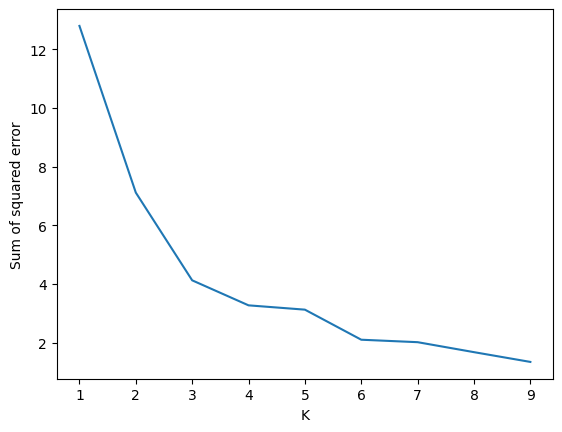

In [56]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)